## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd

import missingno

from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'

In [3]:
years = range(2009, 2024)

In [4]:
datasets = []

for year in years:
    df = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{year}.csv", encoding=enc)
    print(f'Year: {year} | {df.shape}')
    datasets.append(df)

Year: 2009 | (39192, 102)
Year: 2010 | (39192, 102)
Year: 2011 | (39192, 102)
Year: 2012 | (39192, 102)
Year: 2013 | (39192, 102)
Year: 2014 | (39192, 102)
Year: 2015 | (39192, 102)
Year: 2016 | (39192, 102)
Year: 2017 | (39192, 102)
Year: 2018 | (39192, 102)
Year: 2019 | (39192, 102)
Year: 2020 | (39192, 102)
Year: 2021 | (39192, 102)
Year: 2022 | (39192, 102)
Year: 2023 | (39192, 102)


In [5]:
# dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_2016_2018.csv", encoding = enc)
dataset_monthly = pd.concat(datasets, ignore_index=True, axis = 0)
dataset_monthly

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2009-01,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.65882,41.33542,2,2,2,2009,1,0.048867,0.645236,0.695046,-0.645236,0.103399,0.631934,0.587367,-0.631934,0.048829,0.089425,0.114558,0.089425,2.065484,-2.724545,0.066364,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105,8.378167,118.773868,198.685847,259.152060,259.723176,259.723176,-7.790,8.770,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,98.0,10,98.0,4,4,6,4,4,2,0,10.333333,18.500000,45.121951,775.867061,33.0,-8.0,41.0,1.166667,18.833333,18.833333,0.333333,1553.0,259.0,65.0,52.166666,577.0,289.0,368.0,486.0,7608.0,29799.0,10403.0,47810.0,6962.0,29625.0,13770.0,50357.0,1314.36,NaN,NaN
1,0,2009-02,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.65882,41.33542,2,2,2,2009,2,0.048867,0.645236,0.695046,-0.645236,0.103399,0.631934,0.587367,-0.631934,0.048829,0.089425,0.114558,0.089425,1.051429,-3.054286,-1.001429,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105,2.519676,1.651490,12.768820,71.318846,330.274096,70.550920,-8.910,8.370,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,98.0,10,98.0,4,4,6,4,4,2,0,10.333333,18.500000,45.121951,775.867061,33.0,-8.0,41.0,1.166667,18.833333,18.833333,0.333333,1553.0,259.0,65.0,52.166666,577.0,289.0,368.0,486.0,7608.0,29799.0,10403.0,47810.0,6962.0,29625.0,13770.0,50357.0,1314.36,NaN,NaN
2,0,2009-03,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.65882,41.33542,2,2,2,2009,3,0.211360,0.362865,0.190696,-0.362865,0.188228,0.411424,0.260076,-0.411424,0.029014,0.043821,0.062553,0.043821,4.324839,-4.054516,0.135161,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105,5.078133,45.941999,78.429424,147.547585,487.696225,157.422129,-7.770,8.630,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,98.0,10,98.0,4,4,6,4,4,2,0,10.333333,18.500000,45.121951,775.867061,33.0,-8.0,41.0,1.166667,18.833333,18.833333,0.333333,1553.0,259.0,65.0,52.166666,577.0,289.0,368.0,486.0,7608.0,29799.0,10403.0,47810.0,6962.0,29625.0,13770.0,50357.0,1314.36,NaN,NaN
3,0,2009-04,EL5,βορεια ελλαδα,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,23.65882,41.33542,2,2,2,2009,4,0.306158,0.203394,-0.063552,-0.203394,0.287738,0.176433,-0.085433,-0.176433,0.026739,0.038460,0.051437,0.038460,17.039333,3.170667,10.105000,2.065484,1.051429,4.324839,17.039333,-2.724545,-3.054286,-4.054516,3.170667,-0.329531,-1.001429,0.135161,10.105,2.364029,15.493421,50.457857,70.920867,558.617092,70.920867,-1.290,21.650,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,98.0,10,98.0,4,4,6,4,4,2,0,10.333333,18.500000,45.12

In [6]:
# dataset_monthly.cases.sum()

<Axes: >

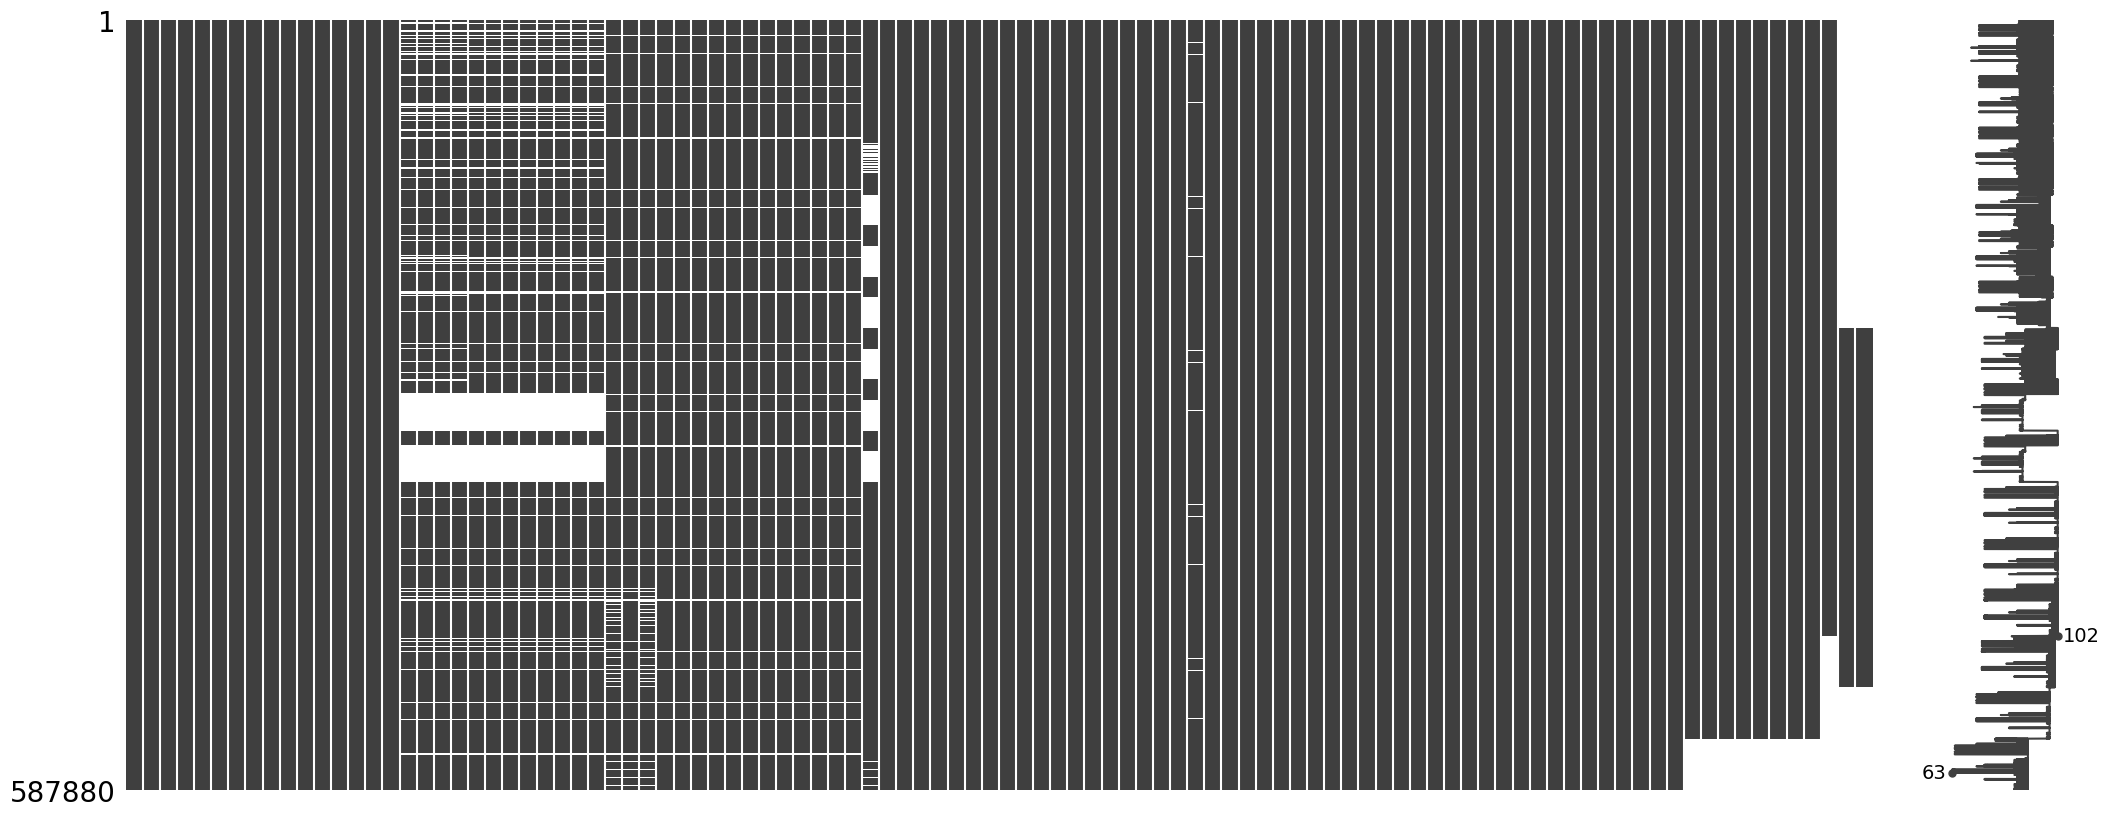

In [7]:
missingno.matrix(dataset_monthly)

In [8]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
16,ndvi,17.9130
17,ndmi,17.9130
18,ndwi,17.9130
19,ndbi,17.9130
20,ndvi_mean,17.2465
...,...,...
97,F_Y_GE65,6.6667
98,F_TOTAL,6.6667
99,MIO_EUR,20.0000
100,L_TOTAL,53.3333


In [9]:
all_columns = dataset_monthly.columns.to_list()

In [10]:
len(dataset_monthly.columns)

102

In [11]:
desired_order = ['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME', 'cell_number', 'x','y','month','year',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst_day_mean','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean',
 'lst_night_mean','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean',
 'lst_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean','lst_min','lst_max',
 'rainfall_mean','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'lc_prop1','lc_prop1_assessment','lc_prop2','lc_prop2_assessment','lc_prop3','lc_prop3_assessment','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw','qc',
 'M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL','MIO_EUR','L_TOTAL','UNL_TOTAL',
 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE',
 ]

In [12]:
len(desired_order)

99

In [13]:
diff1 = set(desired_order) - set(all_columns)
diff2 = set(all_columns) - set(desired_order)

# Combine the differences
result = list(diff1.union(diff2))

In [14]:
result

['NUTS1_NAME', 'rainfall_acc', 'NUTS1_ID']

In [15]:
dataset_monthly = dataset_monthly[desired_order].copy()

In [16]:
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,0,23.65882,41.33542,1,2009,0.048867,0.645236,0.695046,-0.645236,0.103399,0.631934,0.587367,-0.631934,0.048829,0.089425,0.114558,0.089425,2.065484,2.065484,1.051429,4.324839,17.039333,-2.724545,-2.724545,-3.054286,-4.054516,3.170667,0.066364,-0.329531,-1.001429,0.135161,10.105,-7.790,8.770,8.378167,118.773868,198.685847,259.152060,259.723176,10.333333,18.500000,45.121951,775.867061,33.0,-8.0,41.0,1.166667,18.833333,18.833333,0.333333,1553.0,259.0,65.0,52.166666,577.0,289.0,368.0,486.0,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,98.0,10,98.0,4,4,6,4,4,2,0,7608.0,29799.0,10403.0,47810.0,6962.0,29625.0,13770.0,50357.0,1314.36,NaN,NaN,2,2,2
1,2009-02,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,0,23.65882,41.33542,2,2009,0.048867,0.645236,0.695046,-0.645236,0.103399,0.631934,0.587367,-0.631934,0.048829,0.089425,0.114558,0.089425,1.051429,2.065484,1.051429,4.324839,17.039333,-3.054286,-2.724545,-3.054286,-4.054516,3.170667,-1.001429,-0.329531,-1.001429,0.135161,10.105,-8.910,8.370,2.519676,1.651490,12.768820,71.318846,330.274096,10.333333,18.500000,45.121951,775.867061,33.0,-8.0,41.0,1.166667,18.833333,18.833333,0.333333,1553.0,259.0,65.0,52.166666,577.0,289.0,368.0,486.0,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,98.0,10,98.0,4,4,6,4,4,2,0,7608.0,29799.0,10403.0,47810.0,6962.0,29625.0,13770.0,50357.0,1314.36,NaN,NaN,2,2,2
2,2009-03,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,0,23.65882,41.33542,3,2009,0.211360,0.362865,0.190696,-0.362865,0.188228,0.411424,0.260076,-0.411424,0.029014,0.043821,0.062553,0.043821,4.324839,2.065484,1.051429,4.324839,17.039333,-4.054516,-2.724545,-3.054286,-4.054516,3.170667,0.135161,-0.329531,-1.001429,0.135161,10.105,-7.770,8.630,5.078133,45.941999,78.429424,147.547585,487.696225,10.333333,18.500000,45.121951,775.867061,33.0,-8.0,41.0,1.166667,18.833333,18.833333,0.333333,1553.0,259.0,65.0,52.166666,577.0,289.0,368.0,486.0,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,98.0,10,98.0,4,4,6,4,4,2,0,7608.0,29799.0,10403.0,47810.0,6962.0,29625.0,13770.0,50357.0,1314.36,NaN,NaN,2,2,2
3,2009-04,EL51,"ανατολικη μακεδονια, θρακη",EL514,δραμα,κατω νευροκοπιου,0,23.65882,41.33542,4,2009,0.306158,0.203394,-0.063552,-0.203394,0.287738,0.176433,-0.085433,-0.176433,0.026739,0.038460,0.051437,0.038460,17.039333,2.065484,1.051429,4.324839,17.039333,3.170667,-2.724545,-3.054286,-4.054516,3.170667,10.105000,-0.329531,-1.001429,0.135161,10.105,-1.290,21.650,2.364029,15.493421,50.457857,70.920867,558.617092,10.333333,18.500000,45.121951,775.867061,33.0,-8.0,41.0,1.166667,18.833333,18.833333,0.333333,1553.0,259.0,65.0,52.166666,577.0,289.0,368.0,486.0,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,98.0,10,98.0,10,98.0,4,4,6,4,4,2,0,7608.0,29799.0,10403.0,47810.0,6

In [17]:
years = dataset_monthly.year.unique()
months =  dataset_monthly.month.unique()
cell_codes = dataset_monthly.cell_number.unique()

In [18]:
data = []

for year in years[1:]:
    for month in months:
        print(f'Year: {year} | Month: {month}')
        for cell in cell_codes:
            df_regional = dataset_monthly.loc[(dataset_monthly['cell_number'] == cell)].copy()
            df_regional.reset_index(drop = True, inplace = True)

            df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
            if month == 1:
                df_prev_month = df_regional.loc[(df_regional['year'] == year-1) & (df_regional['month'] == 12)].copy()
            else:
                df_prev_month = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month -1)].copy()

            df_curr_year = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month)].copy()
        
            data.append({'cell_number': cell,
                        'nuts2_id': df_curr_year.iloc[0]['NUTS2_ID'],
                        'nuts3_id': df_curr_year.iloc[0]['NUTS3_ID'],
                        'lau1': df_curr_year.iloc[0]['LAU1_NAME'], 
                        'year': year, 
                        'month': month,
                        'x' : df_curr_year.iloc[0]['x'],
                        'y': df_curr_year.iloc[0]['y'],
                        'ndvi': df_prev_month.iloc[0]['ndvi'],
                        'ndmi': df_prev_month.iloc[0]['ndmi'],
                        'ndwi': df_prev_month.iloc[0]['ndwi'],
                        'ndbi': df_prev_month.iloc[0]['ndbi'],
                        'ndvi_mean': df_prev_month.iloc[0]['ndvi_mean'],
                        'ndmi_mean': df_prev_month.iloc[0]['ndmi_mean'],
                        'ndwi_mean': df_prev_month.iloc[0]['ndwi_mean'],
                        'ndbi_mean': df_prev_month.iloc[0]['ndbi_mean'],
                        'ndvi_std': df_prev_month.iloc[0]['ndvi_std'],
                        'ndmi_std': df_prev_month.iloc[0]['ndmi_std'],
                        'ndwi_std': df_prev_month.iloc[0]['ndwi_std'],
                        'ndbi_std': df_prev_month.iloc[0]['ndbi_std'],

                        'lst_day_mean': df_prev_month.iloc[0]['lst_day_mean'],
                        'lst_jan_day_mean': df_curr_year.iloc[0]['lst_jan_day_mean'],
                        'lst_feb_day_mean': df_curr_year.iloc[0]['lst_feb_day_mean'],
                        'lst_mar_day_mean': df_curr_year.iloc[0]['lst_mar_day_mean'],
                        'lst_apr_day_mean': df_curr_year.iloc[0]['lst_apr_day_mean'],

                        'lst_night_mean': df_prev_month.iloc[0]['lst_night_mean'],
                        'lst_jan_night_mean': df_curr_year.iloc[0]['lst_jan_night_mean'],
                        'lst_feb_night_mean': df_curr_year.iloc[0]['lst_feb_night_mean'],
                        'lst_mar_night_mean': df_curr_year.iloc[0]['lst_mar_night_mean'],
                        'lst_apr_night_mean': df_curr_year.iloc[0]['lst_apr_night_mean'],

                        'lst_mean': df_prev_month.iloc[0]['lst_mean'],
                        'lst_jan_mean': df_curr_year.iloc[0]['lst_jan_mean'],
                        'lst_feb_mean': df_curr_year.iloc[0]['lst_feb_mean'],
                        'lst_mar_mean': df_curr_year.iloc[0]['lst_mar_mean'],
                        'lst_apr_mean': df_curr_year.iloc[0]['lst_apr_mean'],

                        'monthly_lst_min': df_prev_month.iloc[0]['lst_min'],
                        'monthly_lst_max': df_prev_month.iloc[0]['lst_max'],

                        'rainfall_mean': df_prev_month.iloc[0]['rainfall_mean'],
                        'acc_rainfall_1week': df_prev_month.iloc[0]['acc_rainfall_1week'],
                        'acc_rainfall_2week': df_prev_month.iloc[0]['acc_rainfall_2week'],
                        'acc_rainfall_month': df_prev_month.iloc[0]['acc_rainfall_month'],
                        'acc_rainfall_jan': df_curr_year.iloc[0]['acc_rainfall_jan'],

                        'bio1': df_prev_year.iloc[0]['bio1'],
                        'bio2': df_prev_year.iloc[0]['bio2'],
                        'bio3': df_prev_year.iloc[0]['bio3'],
                        'bio4': df_prev_year.iloc[0]['bio4'],
                        'bio5': df_prev_year.iloc[0]['bio5'],
                        'bio6': df_prev_year.iloc[0]['bio6'],
                        'bio7': df_prev_year.iloc[0]['bio7'],
                        'bio8': df_prev_year.iloc[0]['bio8'],
                        'bio9': df_prev_year.iloc[0]['bio9'],
                        'bio10': df_prev_year.iloc[0]['bio10'],
                        'bio11': df_prev_year.iloc[0]['bio11'],
                        'bio12': df_prev_year.iloc[0]['bio12'],
                        'bio13': df_prev_year.iloc[0]['bio13'],
                        'bio14': df_prev_year.iloc[0]['bio14'],
                        'bio15': df_prev_year.iloc[0]['bio15'],
                        'bio16': df_prev_year.iloc[0]['bio16'],
                        'bio17': df_prev_year.iloc[0]['bio17'],
                        'bio18': df_prev_year.iloc[0]['bio18'],
                        'bio19': df_prev_year.iloc[0]['bio19'],

                        'lc_prop1': df_curr_year.iloc[0]['lc_prop1'],
                        'lc_prop2': df_curr_year.iloc[0]['lc_prop2'],
                        'lc_prop3': df_curr_year.iloc[0]['lc_prop3'],
                        'lc_type1': df_curr_year.iloc[0]['lc_type1'],
                        'lc_type2': df_curr_year.iloc[0]['lc_type2'],
                        'lc_type3': df_curr_year.iloc[0]['lc_type3'],
                        'lc_type4': df_curr_year.iloc[0]['lc_type4'],
                        'lc_type5': df_curr_year.iloc[0]['lc_type5'],

                        'distance_to_coast': df_curr_year.iloc[0]['distance_to_coast'],
                        'distance_to_river': df_curr_year.iloc[0]['distance_to_river'],
                        'slope_mean_1km': df_curr_year.iloc[0]['slope_mean_1km'],
                        'aspect_mean_200m': df_curr_year.iloc[0]['aspect_mean_200m'],
                        'elevation_mean_1km': df_curr_year.iloc[0]['elevation_mean_1km'],
                        'hillshade_mean_1km': df_curr_year.iloc[0]['hillshade_mean_1km'],
                        'fs_area_1km': df_curr_year.iloc[0]['fs_area_1km'],
                        'flow_accu_200m': df_curr_year.iloc[0]['flow_accu_200m'],

                        'males_lt15': df_prev_year.iloc[0]['M_Y_LT15'],
                        'males_15t64': df_prev_year.iloc[0]['M_Y15-64'],
                        'males_gt65': df_prev_year.iloc[0]['M_Y_GE65'],
                        'males_total': df_prev_year.iloc[0]['M_TOTAL'],
                        'females_lt15': df_prev_year.iloc[0]['F_Y_LT15'],
                        'females_15t64': df_prev_year.iloc[0]['F_Y15-64'],
                        'females_gt65': df_prev_year.iloc[0]['F_Y_GE65'],
                        'females_total': df_prev_year.iloc[0]['F_TOTAL'],
                        'mio_eur': df_prev_year.iloc[0]['MIO_EUR'],
                        'l_total': df_prev_year.iloc[0]['L_TOTAL'],
                        'unl_total': df_prev_year.iloc[0]['UNL_TOTAL'],

                        'mount_type': df_prev_month.iloc[0]['MOUNT_TYPE'],
                        'urbn_type': df_prev_month.iloc[0]['URBN_TYPE'],
                        'coast_type': df_prev_month.iloc[0]['COAST_TYPE'],
                    
                        # 'cases': df_curr_year.iloc[0]['cases'],
                        })
        
dataset_operational = pd.DataFrame(data)       

Year: 2010 | Month: 1
Year: 2010 | Month: 2
Year: 2010 | Month: 3
Year: 2010 | Month: 4
Year: 2010 | Month: 5
Year: 2010 | Month: 6
Year: 2010 | Month: 7
Year: 2010 | Month: 8
Year: 2010 | Month: 9
Year: 2010 | Month: 10
Year: 2010 | Month: 11
Year: 2010 | Month: 12
Year: 2011 | Month: 1
Year: 2011 | Month: 2
Year: 2011 | Month: 3
Year: 2011 | Month: 4
Year: 2011 | Month: 5
Year: 2011 | Month: 6
Year: 2011 | Month: 7
Year: 2011 | Month: 8
Year: 2011 | Month: 9
Year: 2011 | Month: 10
Year: 2011 | Month: 11
Year: 2011 | Month: 12
Year: 2012 | Month: 1
Year: 2012 | Month: 2
Year: 2012 | Month: 3
Year: 2012 | Month: 4
Year: 2012 | Month: 5
Year: 2012 | Month: 6
Year: 2012 | Month: 7
Year: 2012 | Month: 8
Year: 2012 | Month: 9
Year: 2012 | Month: 10
Year: 2012 | Month: 11
Year: 2012 | Month: 12
Year: 2013 | Month: 1
Year: 2013 | Month: 2
Year: 2013 | Month: 3
Year: 2013 | Month: 4
Year: 2013 | Month: 5
Year: 2013 | Month: 6
Year: 2013 | Month: 7
Year: 2013 | Month: 8
Year: 2013 | Month: 9
Y

In [19]:
dataset_monthly[(dataset_monthly['cell_number'] == 0) & (dataset_monthly['year'] == 2017)].drop(columns=['NUTS2_ID','NUTS2_NAME','NUTS3_ID','LAU1_NAME'])

,dt_placement,NUTS3_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
313536,2017-01,δραμα,0,23.65882,41.33542,1,2017,0.167897,0.204567,-0.030945,-0.204567,0.210751,0.147273,-0.166441,-0.147273,0.059477,0.109452,0.094432,0.109452,-0.841613,-0.841613,3.820714,14.864194,17.458,-7.948065,-7.948065,-3.616429,3.502258,4.614,-4.394839,-4.394839,0.102143,9.183226,11.036,-31.07,2.43,3.287161,5.092673,26.064273,101.901978,101.901978,10.041667,21.25,33.730159,1073.113214,32.0,-31.0,63.0,4.5,16.833333,21.166667,-3.666667,1280.0,201.0,30.0,40.976748,432.0,201.0,296.0,427.0,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,99.0,10,99.0,10,99.0,4,4,6,4,4,2,0,6766.0,29259.0,10516.0,46541.0,6389.0,29880.0,14026.0,50295.0,982.37,2888.0,2096.0,2,2,2
313537,2017-02,δραμα,0,23.65882,41.33542,2,2017,0.175173,0.256335,-0.079900,-0.256335,0.137924,0.319690,-0.101221,-0.319690,0.060888,0.079781,0.069434,0.079781,3.820714,-0.841613,3.820714,14.864194,17.458,-3.616429,-7.948065,-3.616429,3.502258,4.614,0.102143,-4.394839,0.102143,9.183226,11.036,-7.99,14.91,2.608024,4.975027,14.624467,73.024681,174.926659,10.041667,21.25,33.730159,1073.113214,32.0,-31.0,63.0,4.5,16.833333,21.166667,-3.666667,1280.0,201.0,30.0,40.976748,432.0,201.0,296.0,427.0,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,99.0,10,99.0,10,99.0,4,4,6,4,4,2,0,6766.0,29259.0,10516.0,46541.0,6389.0,29880.0,14026.0,50295.0,982.37,2888.0,2096.0,2,2,2
313538,2017-03,δραμα,0,23.65882,41.33542,3,2017,0.281388,0.034969,-0.229791,-0.034969,0.270246,-0.005873,-0.247472,0.005873,0.046997,0.075001,0.069567,0.075001,14.864194,-0.841613,3.820714,14.864194,17.458,3.502258,-7.948065,-3.616429,3.502258,4.614,9.183226,-4.394839,0.102143,9.183226,11.036,-2.19,21.93,3.629853,18.666824,22.515020,68.381906,287.452107,10.041667,21.25,33.730159,1073.113214,32.0,-31.0,63.0,4.5,16.833333,21.166667,-3.666667,1280.0,201.0,30.0,40.976748,432.0,201.0,296.0,427.0,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,99.0,10,99.0,10,99.0,4,4,6,4,4,2,0,6766.0,29259.0,10516.0,46541.0,6389.0,29880.0,14026.0,50295.0,982.37,2888.0,2096.0,2,2,2
313539,2017-04,δραμα,0,23.65882,41.33542,4,2017,0.135842,-0.000944,-0.170619,0.000944,0.176543,-0.022782,-0.205259,0.022782,0.047211,0.024004,0.047695,0.024004,17.458000,-0.841613,3.820714,14.864194,17.458,4.614000,-7.948065,-3.616429,3.502258,4.614,11.036000,-4.394839,0.102143,9.183226,11.036,-2.19,24.83,2.457393,12.524212,16.147306,73.721795,361.173902,10.041667,21.25,33.730159,1073.113214,32.0,-31.0,63.0,4.5,16.833333,21.166667,-3.666667,1280.0,201.0,30.0,40.976748,432.0,201.0,296.0,427.0,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,14,99.0,10,99.0,10,99.0,4,4,6,4,4,2,0,6766.0,29259.0,10516.0,46541.0,6389.0,29880.0,14026.0,50295.0,982.37,2888.0,2096.0,2,2,2
313540,2017-05,δραμα,0,23.65882,41.33542,5,2017,0.148813,0.048654,-0.176257,-0.048654,0.197508,0.034015,-0.214914,-0.034015,0.049827,0.023283,0.043787,0.023283,19.742903,-0.841613,3.820714,14.864194,17.458,10.339677,-7.948065

In [20]:
dataset_operational[(dataset_operational['cell_number'] == 0) & (dataset_operational['year'] == 2018)]

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
313536,0,EL51,EL514,κατω νευροκοπιου,2018,1,23.65882,41.33542,0.118628,0.225708,0.002172,-0.225708,0.166330,0.160403,-0.098270,-0.160403,0.065668,0.060549,0.100355,0.060549,2.257097,4.397097,6.644286,9.922258,21.524,-1.473871,-0.402903,-0.282143,2.237097,7.89,0.391613,1.997097,3.181071,6.079677,14.707,-8.81,8.27,4.038921,19.500314,22.209316,84.974539,40.424940,10.041667,21.25,33.730159,1073.113214,32.0,-31.0,63.0,4.5,16.833333,21.166667,-3.666667,1280.0,201.0,30.0,40.976748,432.0,201.0,296.0,427.0,14,10,10,4,4,6,4,4,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,6766.0,29259.0,10516.0,46541.0,6389.0,29880.0,14026.0,50295.0,982.37,2888.0,2096.0,2,2,2
316802,0,EL51,EL514,κατω νευροκοπιου,2018,2,23.65882,41.33542,0.114289,0.191765,0.022532,-0.191765,0.170641,0.117181,-0.093768,-0.117181,0.081984,0.066588,0.108782,0.066588,4.397097,4.397097,6.644286,9.922258,21.524,-0.402903,-0.402903,-0.282143,2.237097,7.89,1.997097,1.997097,3.181071,6.079677,14.707,-8.09,9.23,1.304030,1.035074,24.259168,40.424940,229.401825,10.041667,21.25,33.730159,1073.113214,32.0,-31.0,63.0,4.5,16.833333,21.166667,-3.666667,1280.0,201.0,30.0,40.976748,432.0,201.0,296.0,427.0,14,10,10,4,4,6,4,4,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,6766.0,29259.0,10516.0,46541.0,6389.0,29880.0,14026.0,50295.0,982.37,2888.0,2096.0,2,2,2
320068,0,EL51,EL514,κατω νευροκοπιου,2018,3,23.65882,41.33542,0.222769,0.105849,-0.111198,-0.105849,0.248113,0.056481,-0.188137,-0.056481,0.049899,0.053726,0.085263,0.053726,6.644286,4.397097,6.644286,9.922258,21.524,-0.282143,-0.402903,-0.282143,2.237097,7.89,3.181071,1.997097,3.181071,6.079677,14.707,-5.33,8.71,6.749174,52.659456,67.904113,190.011960,427.697378,10.041667,21.25,33.730159,1073.113214,32.0,-31.0,63.0,4.5,16.833333,21.166667,-3.666667,1280.0,201.0,30.0,40.976748,432.0,201.0,296.0,427.0,14,10,10,4,4,6,4,4,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,6766.0,29259.0,10516.0,46541.0,6389.0,29880.0,14026.0,50295.0,982.37,2888.0,2096.0,2,2,2
323334,0,EL51,EL514,κατω νευροκοπιου,2018,4,23.65882,41.33542,0.293722,0.018614,-0.235396,-0.018614,0.232656,0.061946,-0.222670,-0.061946,0.034425,0.031723,0.053551,0.031723,9.922258,4.397097,6.644286,9.922258,21.524,2.237097,-0.402903,-0.282143,2.237097,7.89,6.079677,1.997097,3.181071,6.079677,14.707,-4.39,18.27,6.396631,4.181057,51.235015,193.408342,457.176891,10.041667,21.25,33.730159,1073.113214,32.0,-31.0,63.0,4.5,16.833333,21.166667,-3.666667,1280.0,201.0,30.0,40.976748,432.0,201.0,296.0,427.0,14,10,10,4,4,6,4,4,13573.304209,975.115126,7,273.211376,1038.457075,164.099283,0.0,4.925067,6766.0,29259.0,10516.0,46541.0,6389.0,29880.0,14026.0,50295.0,982.37,2888.0,2096.0,2,2,2
326600,0,EL51,EL514,κατω νευροκοπιου,2018,5,23.65882,41.33542,0.441659,0.045443,-0.393383,-0.045443,0.419822,0.050334,-0.369687,-0.050334,0.038137,0.032878,0.047098,0.032878,21.524000,4.397097,6.644286,9.922258,21.524,7.890000,-0.402903,-0.282143,2.237097,7.89,14.707000,1.997097,3.181071,6.

<Axes: >

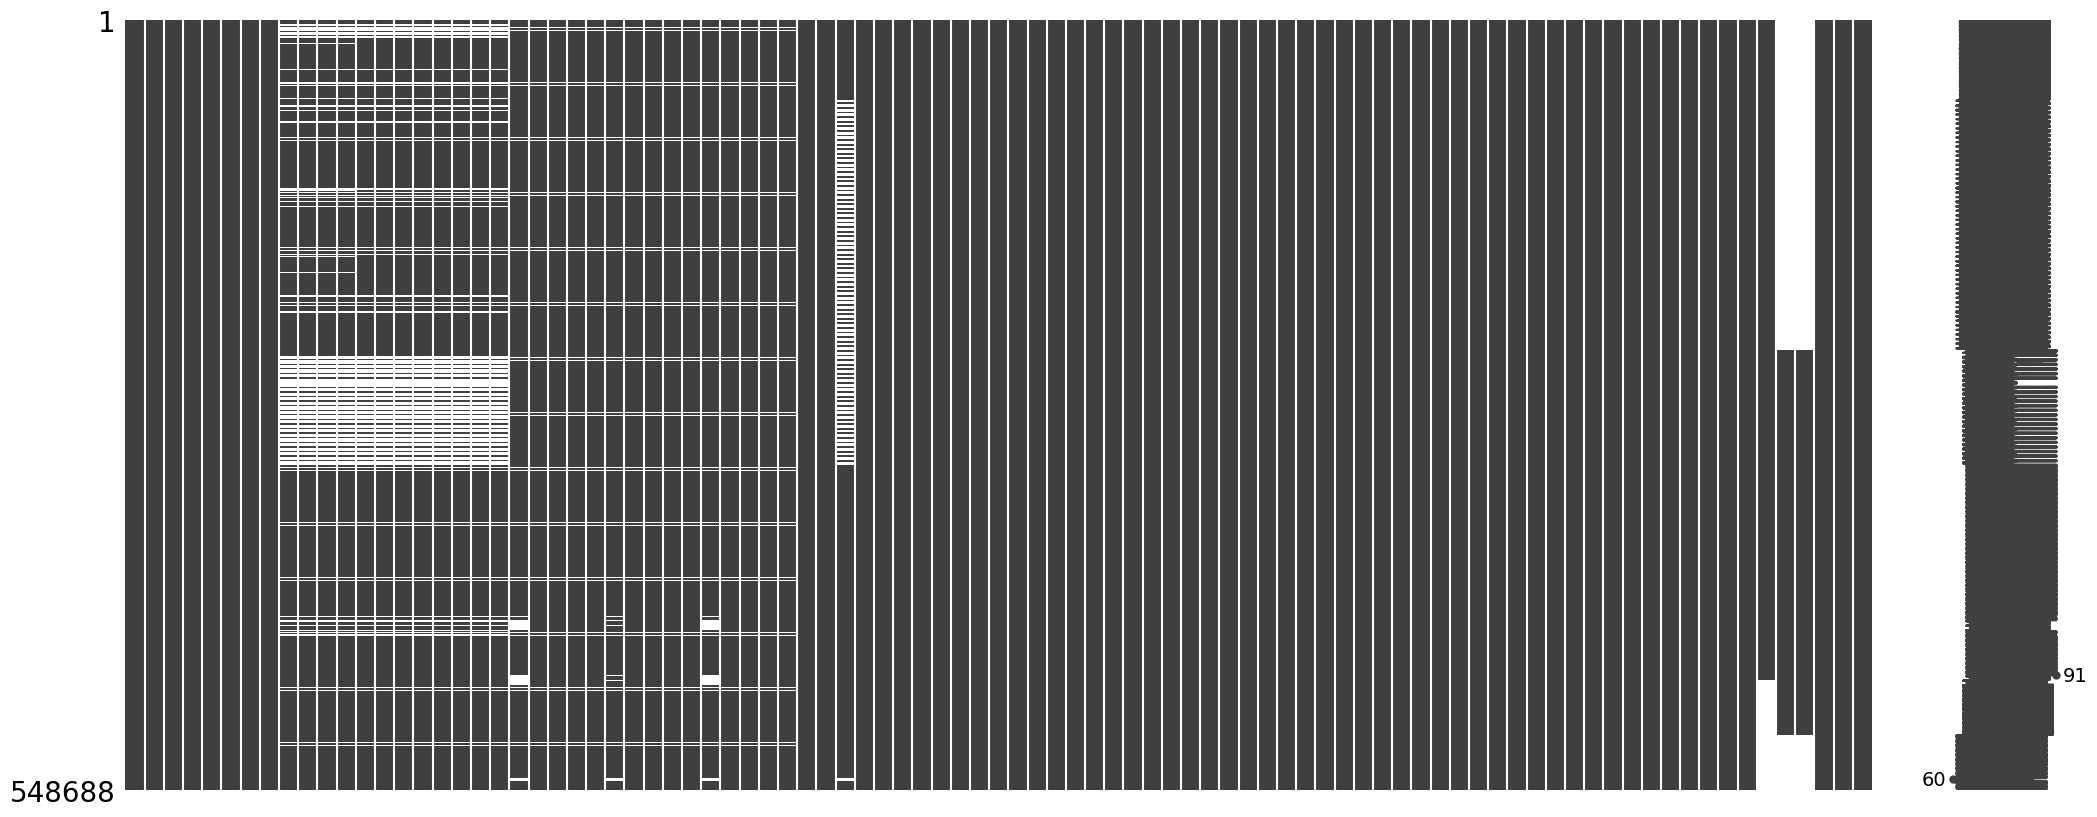

In [21]:
missingno.matrix(dataset_operational)

In [22]:
missing = describe_dataframe(dataset_operational, remove_zeros=True)
missing

,Column,Missing
8,ndvi,17.6082
9,ndmi,17.6082
10,ndwi,17.6082
11,ndbi,17.6082
12,ndvi_mean,16.9812
...,...,...
34,lst_apr_mean,3.9192
37,rainfall_mean,28.8259
85,mio_eur,14.2857
86,l_total,50.0000


In [23]:
# dataset_monthly.cases.sum()

In [24]:
# dataset_operational.cases.sum()

In [25]:
years = dataset_operational.year.unique().tolist()

In [26]:
for item in years:
    dataset_operational[dataset_operational.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_{item}.csv", encoding = enc, index = False)